In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.patches import Patch
import os


os.makedirs('../results/supplementary/', exist_ok=True)
df = pd.read_csv('all.tsv', sep='\t')

methods_order = [
    "threshold_avg",
    "threshold_max",
    "qbc",
    "random"]

method_labels = {
    "threshold_avg": "Threshold Average",
    "threshold_max": "Threshold Max",
    "qbc": "QBC",
    "random": "Random"}


methods_lst = ['grad01_avg', 'grad01_max', 'gradient_conf_avg', 
               'gradient_conf_max', 'gradient_input_avg', 'gradient_input_max', 
               'model_grad_avg', 
               'model_grad_max', 'qbc', 'threshold_avg', 
               'threshold_max', 'feature_eucl', 'random']

base_palette = ["#004949", "#009292", "#ff6db6", 
                "#ffb6db", "#490092", "#006ddb", 
                "#b6dbff", 
                "#920000", "#924900", "#db6d00", 
                "#24ff24", "#ffa500", "#ffff6d"]

user_palette = {methods_lst[i]: base_palette[i] for i in range(len(methods_lst))}
colors = dict(user_palette)


In [2]:
def f1(df, colors, test="test"):
    min_it = int(np.ceil(df["ags_number"].min() / 10.0) * 10)
    max_it = int(np.floor(df["ags_number"].max() / 10.0) * 10)
    x_iters = list(range(min_it, max_it + 1, 10))
    
    num_methods = len(methods_order)

    group_width = 6.0
    offsets = np.linspace(-group_width/2, group_width/2, num_methods)
    
    positions = []
    boxplot_data = []
    box_colors = []
    
    for xi in x_iters:
        for m_idx, method in enumerate(methods_order):
            seg = df[(df["ags_number"] == xi) & (df["method"] == method)][f"roc_aucs_{test}"].dropna().values
            
            if seg.size == 0:
                boxplot_data.append([])
            else:
                boxplot_data.append(seg)
            positions.append(xi + offsets[m_idx])
            box_colors.append(colors.get(method, "#777777"))
    
    filtered_positions = []
    filtered_data = []
    filtered_colors = []
    for pos, data, col in zip(positions, boxplot_data, box_colors):
        if len(data) > 0:
            filtered_positions.append(pos)
            filtered_data.append(data)
            filtered_colors.append(col)
    
    plt.figure(figsize=(14, 6))
    ax = plt.gca()
    bp = plt.boxplot(filtered_data, positions=filtered_positions,
                     widths=group_width/(num_methods+1),
                     patch_artist=True, showfliers=True, boxprops=dict(linewidth=1.0))
    
    for patch, col in zip(bp['boxes'], filtered_colors):
        patch.set_facecolor(col)
        patch.set_alpha(0.95)
    
    for whisker in bp['whiskers']:
        whisker.set(linewidth=0.8)
    for cap in bp['caps']:
        cap.set(linewidth=0.8)
    for median in bp['medians']:
        median.set(color='black', linewidth=1.1)

    dict0 = {'testAB':'TestSharedAG', 'testAG':'TestSharedAB', 'test':'Test'}
    plt.xlabel("Number of iterations", fontsize=14)
    plt.ylabel("ROC AUC", fontsize=14)
    plt.title(f"{dict0[test]}", fontsize=20, pad=12)
    
    plt.xticks(x_iters, x_iters, fontsize=11)
    ax.set_frame_on(False)

    ax.yaxis.grid(False)
    
    legend_handles = [Patch(facecolor=colors[m], edgecolor='k', label=method_labels[m]) for m in methods_order]
    plt.legend(handles=legend_handles, fontsize=11, loc='lower right', bbox_to_anchor=(0.98, 0.14),
               frameon=True, fancybox=True)
    
    plt.tight_layout()
    plt.savefig(f"../results/supplementary/roc_auc_{dict0[test]}_boxplots_grouped.png", dpi=1000)
    plt.show()


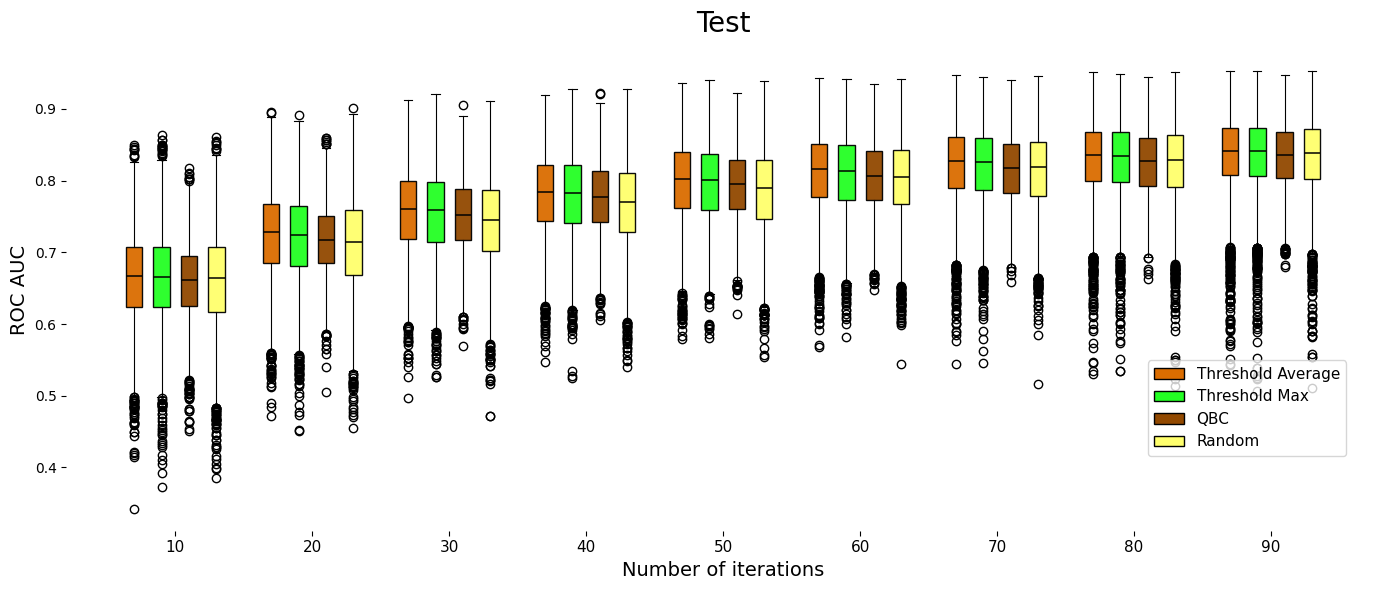

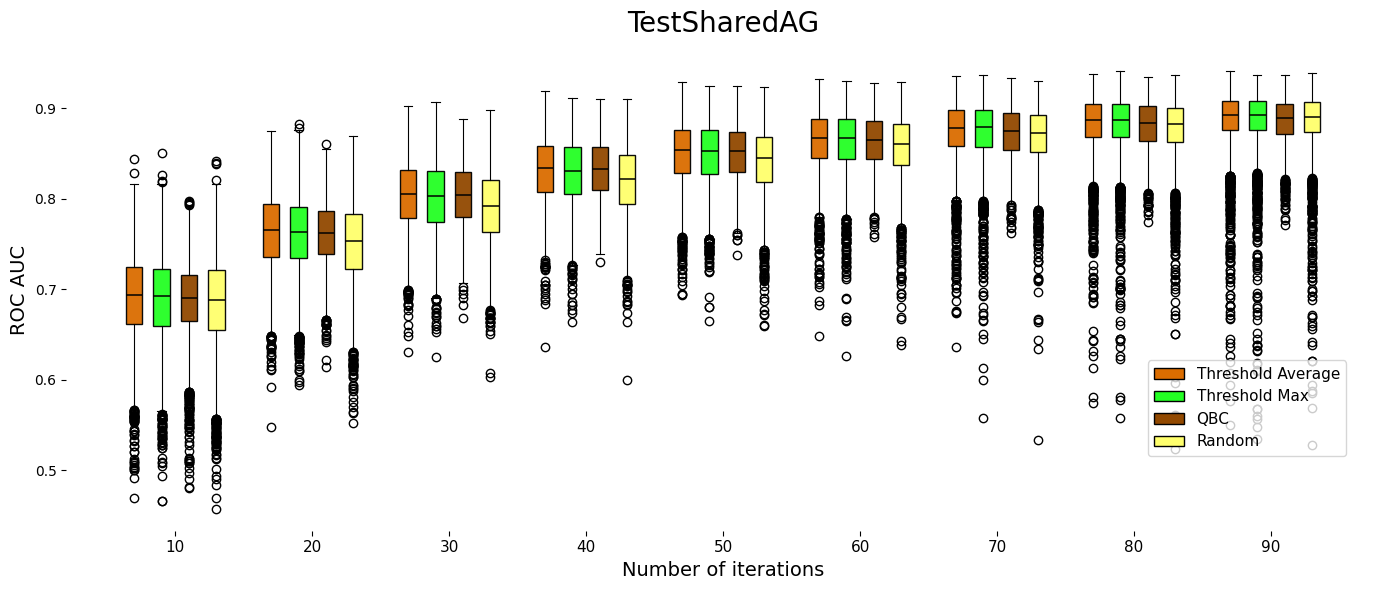

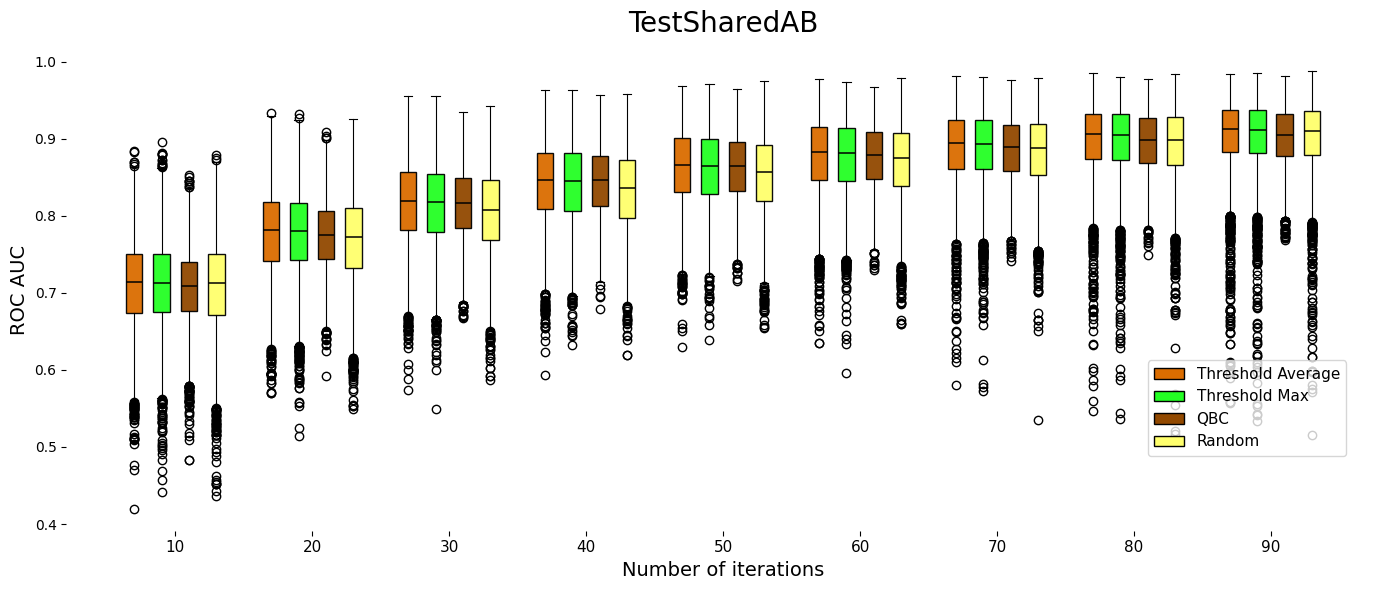

In [3]:
f1(df, colors, test="test")
f1(df, colors, test="testAB")
f1(df, colors, test="testAG")
